# Task 5 - Capstone: redesigning one chart for the human visual system

Data: `gapminder.csv`, 142 countries x 12 survey years (1952-2007, every 5 years).

In [1]:
%matplotlib inline

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

GREY = "#bbbbbb"
GREY_DARK = "#777777"
ACCENT = "#ee6677"
BLUE = "#4477aa"
INK = "#222222"

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titlelocation": "left",
    "axes.titleweight": "bold",
    "text.color": INK,
    "axes.labelcolor": INK,
    "axes.edgecolor": GREY_DARK,
    "xtick.color": GREY_DARK,
    "ytick.color": GREY_DARK,
})


def declutter(ax):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


def save(fig, name):
    fig.savefig(CHARTS / f"{name}.png", dpi=300, bbox_inches="tight")

In [2]:
gap = pd.read_csv(DATA / "gapminder.csv").sort_values(["country", "year"])
print(gap.shape, gap["country"].nunique(), "countries, missing values:", gap.isna().sum().sum())
gap.head()

(1704, 6) 142 countries, missing values: 0


,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


## 1. The bad chart

The one question a reader should be able to answer: **which country broke away from the worldwide rise in life expectancy, and when?**

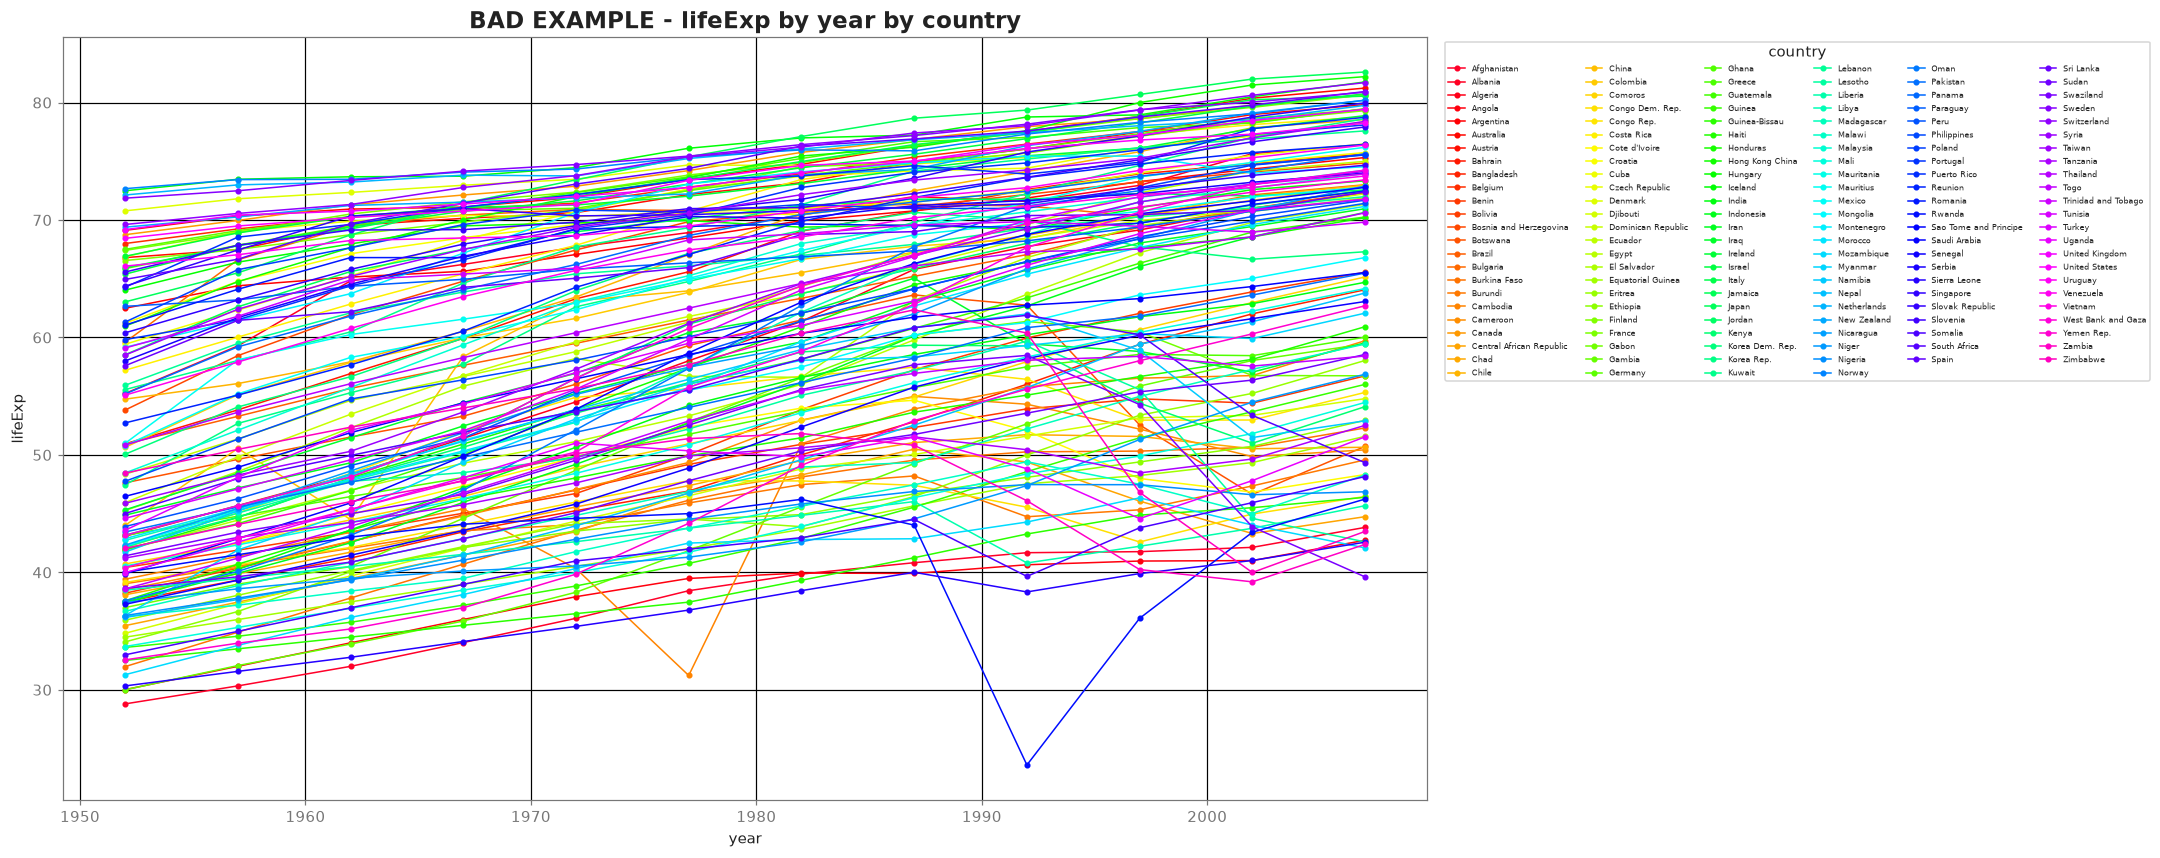

In [3]:
countries = gap["country"].unique()
rainbow = plt.cm.gist_rainbow(np.linspace(0, 1, len(countries)))

fig, ax = plt.subplots(figsize=(16, 9))
for c, col in zip(countries, rainbow):
    d = gap[gap["country"] == c]
    ax.plot(d["year"], d["lifeExp"], color=col, marker="o", markersize=3, linewidth=1, label=c)
ax.grid(True, color="black", linewidth=0.8)
ax.legend(ncol=6, fontsize=5.5, loc="upper left", bbox_to_anchor=(1.01, 1), title="country")
ax.set_title("BAD EXAMPLE - lifeExp by year by country", loc="center", fontsize=15)
ax.set_xlabel("year")
ax.set_ylabel("lifeExp")
save(fig, "task5_bad_spaghetti")
plt.show()

**Chart analysis.**

142 countries, 142 colours, and none of them mean anything.  
You can see one line crash in 1992.  
But you cannot tell which country it is.

## 2. Perception audit of the bad chart

| | Bad chart |
|---|---|
| **Preattentive** | Hue (142 of them), position (x = year, y = life expectancy) and line direction. Position does the useful work. Hue is the strongest attribute on screen but does nothing useful: 142 hues can't be told apart, neighbouring countries in the alphabet get almost the same colour. |
| **Pop-out** | Nothing pops out, or rather everything does. The most saturated colours (bright green, magenta) grab attention by accident. The dip to ~24 years in 1992 does show up because of its shape, but you can't tell which country it is: it's dark blue, and so are Romania, Rwanda, Saudi Arabia, Sao Tome and others in the legend. The title has no claim to check it against. |
| **Gestalt** | Connection: each line joins a country's 12 points, which is right. But continuity fails where lines cross: with 142 lines and similar colours, the eye can't follow one through a crossing. Similarity of hue groups random countries that happen to be next to each other alphabetically. The legend is enclosed in its own box far from the data, so proximity doesn't link names to lines. |
| **Cognitive load** | Intrinsic: 142 countries x 12 years = 1,704 values, plus the overall upward trend. Germane: reading the trend and spotting the exception. Extraneous: 142 colours, 142-entry legend, heavy black grid, point markers on every value, "lifeExp" column-name labels with no units, a title that names axes, no reference to what "normal" is. |
| **Channels** | Life expectancy → y position (rank 1, right). Year → x position (rank 1, right). Country (categorical) → hue, which is OK in principle for categories but only for ~6-8 of them, not 142. |
| **Working memory** | To use the legend the reader has to hold a colour, find it among 142 swatches, read the name, come back and find the line again. One country is already one chunk + a search. Answering the question means comparing several suspect lines, which goes past the 4-chunk limit straight away. |

## 3. The redesign

- **Message:** Rwanda's 1992 collapse.
- **One pop-out:** the Rwanda line, in the one strong colour. It is also thicker and directly labelled, so colour isn't the only thing carrying it.
- **Context:** the other 141 countries in light grey. The yearly median sits in darker grey as the "normal" path to compare against.
- **Gestalt principle used: similarity.** All 141 grey lines look the same, so the eye groups them into one chunk, "the rest of the world". Rwanda is the only line that doesn't match, so it splits off from the group. (Connection is still there, since each country is a line, but similarity is what does the grouping.)
- **Channel:** life expectancy on y position, the highest-ranked channel for a quantity.

In [4]:
median = gap.groupby("year")["lifeExp"].median()
gap["drop"] = gap.groupby("country")["lifeExp"].diff()
worst = gap.loc[gap["drop"].idxmin()]
hero = worst["country"]
h = gap[gap["country"] == hero]
prev = h[h["year"] == worst["year"] - 5]["lifeExp"].iloc[0]
print(worst[["country", "year", "lifeExp", "drop"]])

country    Rwanda
year         1992
lifeExp    23.599
drop      -20.421
Name: 1292, dtype: object


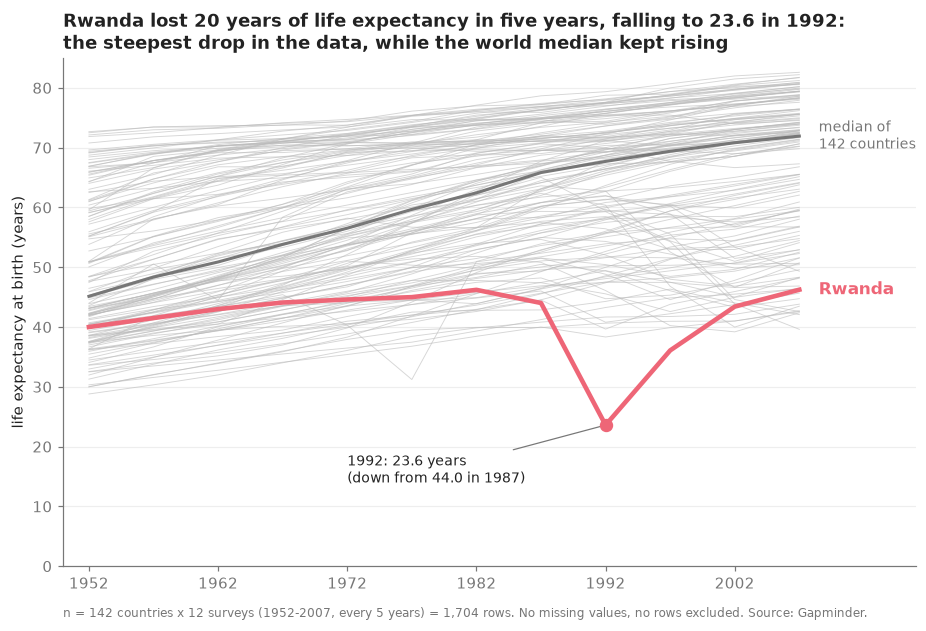

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

for c, d in gap.groupby("country"):
    if c != hero:
        ax.plot(d["year"], d["lifeExp"], color=GREY, linewidth=0.6, alpha=0.6, zorder=1)

ax.plot(median.index, median.values, color=GREY_DARK, linewidth=2, zorder=2)
ax.text(2008.5, median.iloc[-1], "median of\n142 countries", va="center", fontsize=9, color=GREY_DARK)

ax.plot(h["year"], h["lifeExp"], color=ACCENT, linewidth=3, zorder=3)
ax.scatter([worst["year"]], [worst["lifeExp"]], s=60, color=ACCENT, zorder=4)
ax.text(2008.5, h["lifeExp"].iloc[-1], hero, va="center", fontsize=11, color=ACCENT, fontweight="bold")
ax.annotate(f"{int(worst['year'])}: {worst['lifeExp']:.1f} years\n(down from {prev:.1f} in {int(worst['year']) - 5})",
            xy=(worst["year"], worst["lifeExp"]), xytext=(1972, 14),
            fontsize=9, color=INK, arrowprops={"arrowstyle": "-", "color": GREY_DARK, "linewidth": 0.8})

ax.set_xlim(1950, 2016)
ax.set_ylim(0, 85)
ax.set_xticks(range(1952, 2008, 10))
ax.set_ylabel("life expectancy at birth (years)")
ax.set_title(f"{hero} lost {abs(worst['drop']):.0f} years of life expectancy in five years, "
             f"falling to {worst['lifeExp']:.1f} in {int(worst['year'])}:\nthe steepest drop "
             f"in the data, while the world median kept rising")
ax.grid(axis="y", color="#eeeeee")
ax.set_axisbelow(True)
declutter(ax)
ax.text(0, -0.1, "n = 142 countries x 12 surveys (1952-2007, every 5 years) = 1,704 rows. "
        "No missing values, no rows excluded. Source: Gapminder.",
        transform=ax.transAxes, fontsize=8, color=GREY_DARK)

fig.savefig("perception_redesign.png", dpi=300, bbox_inches="tight")
save(fig, "task5_redesign")
plt.show()

**Chart analysis.**

Every other country is grey, so they read as one background group.  
Rwanda is the only coloured line, so the eye goes straight to it.  
Colour, thickness and a label all point the same way.

## 4. Audit, before and after

| | Bad chart | Redesign |
|---|---|---|
| **Preattentive** | 142 hues fighting, none meaningful | one hue (red) + line width, used once; everything else grey |
| **Pop-out** | nothing / random bright lines | exactly one: the Rwanda line, which is what the title claims |
| **Gestalt** | connection per line, but continuity breaks at crossings; legend far away | similarity groups 141 grey lines into one "rest of world" chunk; direct labels use proximity; connection keeps each country a line |
| **Cognitive load** | extraneous: 142 colours, legend, heavy grid, markers, no units, axis-name title | removed all of those. Added a median line, an annotation and units: that's added ink, but it removes a calculation (what's normal? how big was the drop?) |
| **Channels** | value → y position (good), country → hue (fails at 142) | value → y position, year → x position. Country identity only needed for one line, done by label + colour + width |
| **Working memory** | colour → legend → name → back, per country; well over 4 chunks | three chunks: the grey crowd, the median, Rwanda. Plus the annotation, which is read in place |

## 5. Testing it on someone who hasn't seen the data

Shown: `perception_redesign.png` only, with no explanation from me.

**Reader:** _(name / "a classmate")_

**Their sentence, word for word:** _"..."_

**Does it match my title?** _(yes / partly / no)_ - _(If not, what misled them. E.g. if they said "life expectancy went up everywhere", the red line wasn't strong enough against the grey. If they read the median as one country, its label needs to be clearer. Say what you'd change next.)_

## Self-audit

- [x] every chart built with `fig, ax` (no `plt.plot` / `plt.bar`)
- [x] exactly one pop-out (Rwanda), and it carries the title's message
- [x] Gestalt principle named: similarity
- [x] most important variable (life expectancy) on y position
- [x] every element classified intrinsic / extraneous / germane (audit table)
- [x] reader holds about 3 chunks
- [x] Rwanda isn't shown by colour alone: thicker line, direct label, annotation
- [x] context grey, message red
- [x] n and exclusions on the figure
- [x] title states a finding
- [ ] a real reader's sentence recorded word for word - _(tick after section 5)_

## The question: what does the redesign make harder to see?

Everything that isn't Rwanda. The clearest loss is the **southern African life-expectancy decline of the 1990s-2000s** (HIV/AIDS). Zimbabwe dropped about 19 years between 1987 and 2007, Swaziland about 18, Lesotho about 15, Botswana about 13. Over 20 years that's a bigger, longer-lasting loss than Rwanda's. Rwanda recovered to 46 by 2007, but in my chart those countries are just a few grey lines dipping inside the crowd. Cambodia's 1977 drop (Khmer Rouge) disappears the same way. Continents also vanish completely: the bad chart couldn't show them either, but the redesign makes it impossible to tell that most of the bottom lines are African countries.

So choosing "the sharpest single drop" as the message hides "the biggest long-term reversal". If that were the story, I'd keep the same layout but highlight the southern African group instead. That would be a different chart, not an extra colour on this one.